In [4]:
import pandas as pd
from collections import deque
import matplotlib.pyplot as plt

# =========================
# CARREGAMENTO DOS DADOS
# =========================

df = pd.read_csv('./Check_point_1_dados_logistica_RA_final_par.csv')

In [ ]:

# =========================
# CLASSIFICAÇÃO DE VALOR (lambda)
# =========================

# Valor total do pedido
# Complexidade: O(n)
df["valor_total"] = df["quantidade"] * df["valor_unitario"]

# Faixa de valor
# Complexidade: O(n)
df["faixa_valor"] = df["valor_total"].apply(
    lambda x: "alto" if x >= 2000 else "medio" if x >= 1000 else "baixo"
)

In [6]:

# =========================
# SCORE BASE (mesma ideia do ímpar)
# =========================
# Complexidade: O(n)

df["valor_prioridade"] = 0

# Urgência
df["valor_prioridade"] += df["urgencia"].map({
    "alta": 3,
    "media": 2,
    "baixa": 1
})

# Tempo estimado (quanto menor, maior prioridade)
df["valor_prioridade"] += (df["tempo_estimado_horas"].max() - df["tempo_estimado_horas"]).clip(0)

# Valor financeiro
df["valor_prioridade"] += df["faixa_valor"].map({
    "alto": 2,
    "medio": 1
}).fillna(0)

# Status de pagamento
df["valor_prioridade"] += df["status_pagamento"].map({
    "ok": 2,
    "pendente": 0
})

In [7]:

# =========================
# INTERAÇÕES (REGRAS DE NEGÓCIO)
# =========================

df["valor_prioridade"] += (
    (df["urgencia"] == "alta") &
    (df["tempo_estimado_horas"] <= 12)
) * 3

df["valor_prioridade"] += (
    (df["faixa_valor"] == "alto") &
    (df["status_pagamento"] == "ok")
) * 2

# =========================
# NORMALIZAÇÃO
# =========================

df["valor_prioridade"] = df["valor_prioridade"].clip(3, 12)


In [8]:

# =========================
# CLASSIFICAÇÃO FINAL
# =========================

def classificar_prioridade(p):
    if p >= 8:
        return "alta"
    elif p >= 5:
        return "media"
    return "baixa"

df["categoria_prioridade"] = df["valor_prioridade"].apply(classificar_prioridade)

# =========================
# ORDENAÇÃO
# =========================
# Complexidade: O(n log n)

df = df.sort_values(by="valor_prioridade", ascending=False)

# =========================
# OUTPUT
# =========================

print("\nTabela final:")
print(df)



Tabela final:
   pedido_id cidade_destino produto categoria  quantidade  valor_unitario  \
0          1             SP   Arroz  Alimento         100               5   
3          4             BA    Soja  Alimento         300               7   
4          5             PR    Cafe  Alimento         250              10   
2          3             MG   Milho  Alimento         150               4   
1          2             RJ  Feijao  Alimento         200               6   

  urgencia  tempo_estimado_horas        modal status_pagamento  valor_total  \
0     alta                    10   rodoviario               ok          500   
3     alta                    12  ferroviario               ok         2100   
4    media                    18   rodoviario               ok         2500   
2    baixa                    15   rodoviario         pendente          600   
1    media                    20  ferroviario               ok         1200   

  faixa_valor  valor_prioridade categoria_prior

In [9]:
# =========================
# RECURSÃO
# =========================

def processar_pedidos_recursivo(lista, index=0):
    # Complexidade: O(n)
    if index >= len(lista):
        return []

    pedido = lista[index]

    resultado = {
        "id": pedido["pedido_id"],
        "prioridade": pedido["valor_prioridade"],
        "categoria": pedido["categoria_prioridade"]
    }

    return [resultado] + processar_pedidos_recursivo(lista, index + 1)

lista_dict = df.to_dict(orient="records")
resultado_recursivo = processar_pedidos_recursivo(lista_dict)

print("\nProcessamento recursivo:")
print(resultado_recursivo)


Processamento recursivo:
[{'id': 1, 'prioridade': 12.0, 'categoria': 'alta'}, {'id': 4, 'prioridade': 12.0, 'categoria': 'alta'}, {'id': 5, 'prioridade': 10.0, 'categoria': 'alta'}, {'id': 3, 'prioridade': 6.0, 'categoria': 'media'}, {'id': 2, 'prioridade': 5.0, 'categoria': 'media'}]


In [10]:

# =========================
# LISTA
# =========================

lista_ids = df["pedido_id"].tolist()

# =========================
# DEQUE
# =========================

fila = deque(lista_ids)

print("\nFila de pedidos:")
print(fila)

while fila:
    pedido = fila.popleft()
    print(f"Processando pedido {pedido}")

# =========================
# DICIONÁRIO + TUPLA
# =========================

mapa = {
    row["pedido_id"]: (row["cidade_destino"], row["modal"])
    for _, row in df.iterrows()
}

print("\nMapa de pedidos:")
print(mapa)


Fila de pedidos:
deque([1, 4, 5, 3, 2])
Processando pedido 1
Processando pedido 4
Processando pedido 5
Processando pedido 3
Processando pedido 2

Mapa de pedidos:
{1: ('SP', 'rodoviario'), 4: ('BA', 'ferroviario'), 5: ('PR', 'rodoviario'), 3: ('MG', 'rodoviario'), 2: ('RJ', 'ferroviario')}


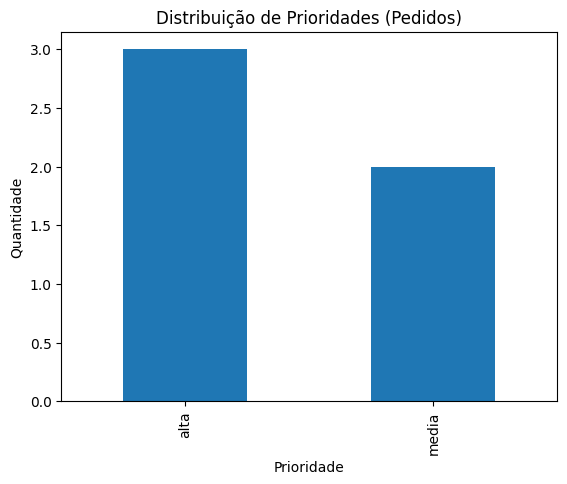

In [11]:

# =========================
# CONTAGEM
# =========================

contagem = df["categoria_prioridade"].value_counts()

# =========================
# GRÁFICO
# =========================

plt.figure()
contagem.plot(kind="bar")
plt.xlabel("Prioridade")
plt.ylabel("Quantidade")
plt.title("Distribuição de Prioridades (Pedidos)")
plt.show()